In [167]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_covtype
import random
import warnings
import os

In [168]:
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [169]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [170]:
CONFIG = {
    'pop_size': 50,
    'generations': 70,
    'mutation_rate': 0.15,
    'elitism_count': 3,
    'penalty_weight': 0.01,
    'num_experts': 6,
    'expert_epochs': 12,
    'patience': 4,
    'lr': 1e-3
}

In [171]:
class DataPipeline:
    def __init__(self, n_samples=150000):
        data = fetch_covtype()
        X, y = data.data.astype(np.float32), (data.target - 1).astype(np.int64)
        self.feature_names = list(data.feature_names)
        self.num_classes = 7
        
        if n_samples < len(X):
            idx = np.random.choice(len(X), n_samples, replace=False)
            X, y = X[idx], y[idx]
            
        X_tr_val, self.X_test, y_tr_val, self.y_test = train_test_split(
            X, y, test_size=0.15, random_state=42, stratify=y)
            
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_tr_val, y_tr_val, test_size=0.15, random_state=42, stratify=y_tr_val)
            
        self.scaler = StandardScaler().fit(self.X_train)
        self.X_train = self.scaler.transform(self.X_train)
        self.X_val = self.scaler.transform(self.X_val)
        self.X_test = self.scaler.transform(self.X_test)
        
        selector = ExtraTreesClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
        selector.fit(self.X_train, self.y_train)
        importances = selector.feature_importances_
        self.top_features = np.argsort(importances)[-2:]
        print(f"Отобранные признаки для переключения: {self.feature_names[self.top_features[0]]}, {self.feature_names[self.top_features[1]]}")
        
    def get_torch_data(self, split='val'):
        X = getattr(self, f'X_{split}')
        y = getattr(self, f'y_{split}')
        return torch.tensor(X, device=device), torch.tensor(y, device=device)

pipeline = DataPipeline()

Отобранные признаки для переключения: Horizontal_Distance_To_Roadways, Elevation


In [172]:
ACT_MAP = {'relu': nn.ReLU, 'tanh': nn.Tanh, 'sigmoid': nn.Sigmoid, 'leakyrelu': nn.LeakyReLU}
EXPERT_DIR = 'expert_pool'
os.makedirs(EXPERT_DIR, exist_ok=True)

def build_arch(hidden, neurons, act, reg):
    layers = []
    prev = pipeline.X_train.shape[1]
    for n in neurons:
        layers.append(nn.Linear(prev, n))
        layers.append(ACT_MAP[act]())
        prev = n
    layers.append(nn.Linear(prev, pipeline.num_classes))
    return nn.Sequential(*layers)

def train_expert(model, epochs, patience, lr, reg):
    optimizer = optim.Adam(model.parameters(), weight_decay=reg, lr=lr)
    criterion = nn.CrossEntropyLoss()
    X_tr, y_tr = pipeline.get_torch_data('train')
    X_v, y_v = pipeline.get_torch_data('val')
    
    best_loss, patience_cnt, best_state = float('inf'), 0, None
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            v_loss = criterion(model(X_v), y_v).item()
            
        if v_loss < best_loss:
            best_loss = v_loss; patience_cnt = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= patience: break
            
    model.load_state_dict(best_state)
    model.eval()
    return model

In [173]:
EXPERT_CONFIGS = [
    {'hidden': 1, 'neurons': [64], 'act': 'relu', 'reg': 0.0},
    {'hidden': 2, 'neurons': [48, 32], 'act': 'tanh', 'reg': 0.001},
    {'hidden': 3, 'neurons': [64, 32, 16], 'act': 'leakyrelu', 'reg': 0.01},
    {'hidden': 2, 'neurons': [96, 64], 'act': 'sigmoid', 'reg': 0.0},
    {'hidden': 3, 'neurons': [128, 64, 32], 'act': 'relu', 'reg': 0.005},
    {'hidden': 1, 'neurons': [128], 'act': 'tanh', 'reg': 0.01}
]

In [174]:
experts = []
for i, cfg in enumerate(EXPERT_CONFIGS):
    path = os.path.join(EXPERT_DIR, f'expert_{i}.pt')
    if os.path.exists(path):
        print(f"[{i}] Загрузка из файла...")
        model = build_arch(**cfg).to(device)
        model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        experts.append(model)
    else:
        print(f"[{i}] Обучение...")
        model = build_arch(**cfg).to(device)
        model = train_expert(model, CONFIG['expert_epochs'], CONFIG['patience'], CONFIG['lr'], cfg['reg'])
        torch.save(model.state_dict(), path)
        experts.append(model)

[0] Обучение...
[1] Обучение...
[2] Обучение...
[3] Обучение...
[4] Обучение...
[5] Обучение...


In [175]:
with torch.no_grad():
    X_val_t = torch.tensor(pipeline.X_val, device=device)
    expert_preds_val = np.stack([e(X_val_t).cpu().numpy() for e in experts])

In [176]:
class DirectorIndividual:
    def __init__(self, mask=None, thresholds=None, routing=None):
        n = CONFIG['num_experts']
        self.mask = mask if mask is not None else (np.random.rand(n) > 0.4).astype(int)
        if not np.any(self.mask): self.mask[np.random.randint(n)] = 1
        self.thresholds = thresholds if thresholds is not None else np.random.uniform(-2.0, 2.0, 2)
        self.routing = routing if routing is not None else np.random.randint(-1, n, 4)
        
    @property
    def n_active(self): return np.sum(self.mask)

def evaluate_director(ind, expert_preds, y_true, penalty=0.01, f_indices=None):
    t1, t2 = ind.thresholds
    f1, f2 = f_indices
    X = pipeline.X_val
    
    q = ((X[:, f1] > t1).astype(int) * 2 + (X[:, f2] > t2).astype(int))
    preds = np.zeros((len(X), pipeline.num_classes))
    active = np.where(ind.mask == 1)[0]
    
    for r in range(4):
        mask_r = (q == r)
        if not np.any(mask_r): continue
        target_idx = ind.routing[r]
        if target_idx in active:
            preds[mask_r] = expert_preds[target_idx][mask_r]
        else:
            preds[mask_r] = np.mean(expert_preds[active][:, mask_r], axis=0)
            
    y_pred = np.argmax(preds, axis=1)
    acc = accuracy_score(y_true, y_pred)
    ind.fitness = acc - (penalty * ind.n_active)
    return ind.fitness

In [177]:
class CustomGA:
    def __init__(self):
        self.pop = [DirectorIndividual() for _ in range(CONFIG['pop_size'])]
        self.history = {'best': [], 'avg': []}
        
    def tournament(self, k=3):
        return max(random.sample(self.pop, k), key=lambda x: x.fitness)
    
    def crossover(self, p1, p2):
        c_mask = np.where(np.random.rand(len(p1.mask)) < 0.5, p1.mask, p2.mask)
        if not np.any(c_mask): c_mask[np.random.randint(len(c_mask))] = 1
        c_thresh = np.clip(np.random.rand(2) * p1.thresholds + (1-np.random.rand(2)) * p2.thresholds, -3.0, 3.0)
        c_route = np.where(np.random.rand(4) < 0.5, p1.routing, p2.routing)
        return DirectorIndividual(c_mask, c_thresh, c_route)
    
    def mutate(self, ind, rate=CONFIG['mutation_rate']):
        if random.random() < rate:
            flip = np.random.randint(len(ind.mask))
            ind.mask[flip] = 1 - ind.mask[flip]
            if not np.any(ind.mask): ind.mask[np.random.randint(len(ind.mask))] = 1
        if random.random() < rate:
            idx = np.random.randint(2)
            ind.thresholds[idx] += np.random.normal(0, 0.3)
            ind.thresholds[idx] = np.clip(ind.thresholds[idx], -3.0, 3.0)
        if random.random() < rate:
            idx = np.random.randint(4)
            ind.routing[idx] = np.random.randint(-1, CONFIG['num_experts'])
        return ind
        
    def run(self):
        for ind in self.pop:
            evaluate_director(ind, expert_preds_val, pipeline.y_val, CONFIG['penalty_weight'], pipeline.top_features)
            
        for gen in range(CONFIG['generations']):
            self.pop.sort(key=lambda x: x.fitness, reverse=True)
            self.history['best'].append(self.pop[0].fitness)
            self.history['avg'].append(np.mean([i.fitness for i in self.pop]))
            
            new_pop = self.pop[:CONFIG['elitism_count']]
            while len(new_pop) < CONFIG['pop_size']:
                p1, p2 = self.tournament(), self.tournament()
                child = self.mutate(self.crossover(p1, p2))
                evaluate_director(child, expert_preds_val, pipeline.y_val, CONFIG['penalty_weight'], pipeline.top_features)
                new_pop.append(child)
            self.pop = new_pop
            
            print(f"Gen {gen+1}/{CONFIG['generations']} | Best: {self.pop[0].fitness:.4f} | Active: {self.pop[0].n_active}")
            
        return self.pop[0]

In [178]:
ga = CustomGA()
best_ind = ga.run()

Gen 1/70 | Best: 0.5924 | Active: 3
Gen 2/70 | Best: 0.5924 | Active: 3
Gen 3/70 | Best: 0.5961 | Active: 3
Gen 4/70 | Best: 0.5961 | Active: 3
Gen 5/70 | Best: 0.5961 | Active: 3
Gen 6/70 | Best: 0.6070 | Active: 4
Gen 7/70 | Best: 0.6070 | Active: 4
Gen 8/70 | Best: 0.6097 | Active: 4
Gen 9/70 | Best: 0.6097 | Active: 4
Gen 10/70 | Best: 0.6097 | Active: 4
Gen 11/70 | Best: 0.6097 | Active: 4
Gen 12/70 | Best: 0.6097 | Active: 4
Gen 13/70 | Best: 0.6097 | Active: 4
Gen 14/70 | Best: 0.6097 | Active: 4
Gen 15/70 | Best: 0.6116 | Active: 4
Gen 16/70 | Best: 0.6122 | Active: 3
Gen 17/70 | Best: 0.6135 | Active: 3
Gen 18/70 | Best: 0.6135 | Active: 3
Gen 19/70 | Best: 0.6135 | Active: 3
Gen 20/70 | Best: 0.6135 | Active: 3
Gen 21/70 | Best: 0.6135 | Active: 3
Gen 22/70 | Best: 0.6135 | Active: 3
Gen 23/70 | Best: 0.6135 | Active: 3
Gen 24/70 | Best: 0.6135 | Active: 3
Gen 25/70 | Best: 0.6135 | Active: 3
Gen 26/70 | Best: 0.6144 | Active: 3
Gen 27/70 | Best: 0.6144 | Active: 3
Gen 28/70 

In [179]:
print(f"Финальная точность (Fitness): {best_ind.fitness:.4f}")
print(f"Активные модели: {[i for i, m in enumerate(best_ind.mask) if m == 1]}")
print(f"Пороги ({pipeline.feature_names[pipeline.top_features[0]]}, {pipeline.feature_names[pipeline.top_features[1]]}): {best_ind.thresholds.round(2)}")
print("Логика переключения:")
zones = ["X1>t1, X2>t2", "X1>t1, X2≤t2", "X1≤t1, X2>t2", "X1≤t1, X2≤t2"]
for q, desc in enumerate(zones):
    r = best_ind.routing[q]
    action = f"Модель No {r}" if r != -1 else "Среднее всех активных"
    print(f"  {desc} -> {action}")

Финальная точность (Fitness): 0.6177
Активные модели: [1, 4, 5]
Пороги (Horizontal_Distance_To_Roadways, Elevation): [1.85 0.49]
Логика переключения:
  X1>t1, X2>t2 -> Среднее всех активных
  X1>t1, X2≤t2 -> Модель No 4
  X1≤t1, X2>t2 -> Модель No 1
  X1≤t1, X2≤t2 -> Среднее всех активных


In [180]:
def get_zone_predictions(ind, X, f_idx):
    t1, t2 = ind.thresholds
    q = ((X[:, f_idx[0]] > t1).astype(int) * 2 + (X[:, f_idx[1]] > t2).astype(int))
    preds = np.zeros((len(X), pipeline.num_classes))
    active = np.where(ind.mask == 1)[0]
    for r in range(4):
        mask_r = (q == r)
        target = ind.routing[r]
        if target in active:
            preds[mask_r] = expert_preds_val[target][mask_r]
        else:
            preds[mask_r] = np.mean(expert_preds_val[active][:, mask_r], axis=0)
    return np.argmax(preds, axis=1), q

In [181]:
X_test_t = torch.tensor(pipeline.X_test, device=device)
expert_preds_test = np.stack([e(X_test_t).detach().cpu().numpy() for e in experts]) 

def eval_test(ind):
    t1, t2 = ind.thresholds
    f1, f2 = pipeline.top_features
    X = pipeline.X_test
    q = ((X[:, f1] > t1).astype(int) * 2 + (X[:, f2] > t2).astype(int))
    preds = np.zeros((len(X), pipeline.num_classes))
    active = np.where(ind.mask == 1)[0]
    for r in range(4):
        mask_r = (q == r)
        if not np.any(mask_r): continue
        target = ind.routing[r]
        if target in active:
            preds[mask_r] = expert_preds_test[target][mask_r]
        else:
            preds[mask_r] = np.mean(expert_preds_test[active][:, mask_r], axis=0)
    return accuracy_score(pipeline.y_test, np.argmax(preds, axis=1))

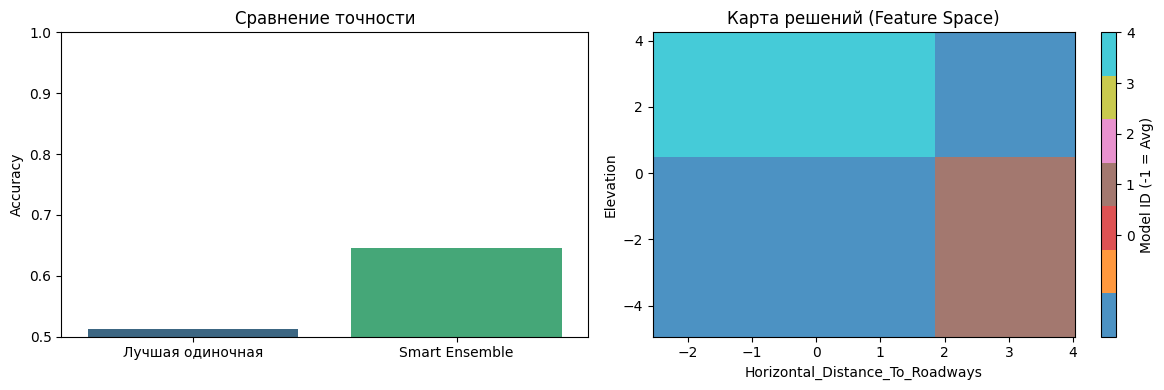

In [182]:
ens_acc = eval_test(best_ind)
best_single_acc = max(eval_test(DirectorIndividual(np.eye(1, CONFIG['num_experts'], i).flatten().astype(int), best_ind.thresholds, best_ind.routing)) for i in range(CONFIG['num_experts']))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=['Лучшая одиночная', 'Smart Ensemble'], y=[best_single_acc, ens_acc], ax=ax[0], palette='viridis')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Сравнение точности')
ax[0].set_ylim(0.5, 1.0)

x1_min, x1_max = pipeline.X_test[:, pipeline.top_features[0]].min() - 1, pipeline.X_test[:, pipeline.top_features[0]].max() + 1
x2_min, x2_max = pipeline.X_test[:, pipeline.top_features[1]].min() - 1, pipeline.X_test[:, pipeline.top_features[1]].max() + 1
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))

q_grid = ((xx > best_ind.thresholds[0]).astype(int) * 2 + (yy > best_ind.thresholds[1]).astype(int))
Z = np.array([best_ind.routing[q] if best_ind.routing[q] != -1 else -2 for q in q_grid.ravel()]).reshape(xx.shape)

cmap = plt.get_cmap('tab10', CONFIG['num_experts']+1)
im = ax[1].pcolormesh(xx, yy, Z, cmap=cmap, shading='auto', alpha=0.8)
ax[1].set_xlabel(pipeline.feature_names[pipeline.top_features[0]])
ax[1].set_ylabel(pipeline.feature_names[pipeline.top_features[1]])
ax[1].set_title('Карта решений (Feature Space)')
plt.colorbar(im, ax=ax[1], ticks=np.arange(CONFIG['num_experts']+1), label='Model ID (-1 = Avg)')
plt.tight_layout()
plt.show()

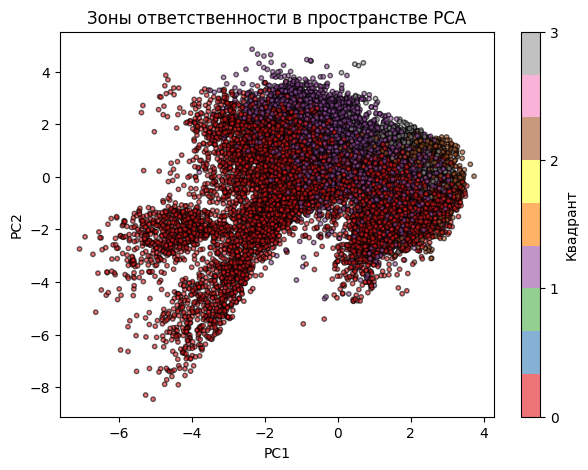

In [183]:
pca = PCA(n_components=2).fit(pipeline.X_test)
X_pca = pca.transform(pipeline.X_test)
zones_test = ((pipeline.X_test[:, pipeline.top_features[0]] > best_ind.thresholds[0]).astype(int) * 2 + 
              (pipeline.X_test[:, pipeline.top_features[1]] > best_ind.thresholds[1]).astype(int))
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=zones_test, cmap='Set1', alpha=0.6, edgecolor='k', s=10)
plt.title('Зоны ответственности в пространстве PCA')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(scatter, ticks=np.arange(4), label='Квадрант')
plt.show()

In [184]:
t1, t2 = best_ind.thresholds
f1, f2 = pipeline.top_features
X_test = pipeline.X_test
y_test = pipeline.y_test

zones_test = ((X_test[:, f1] > t1).astype(int) * 2 + (X_test[:, f2] > t2).astype(int))

zone_names = ["X1>t1, X2>t2", "X1>t1, X2≤t2", "X1≤t1, X2>t2", "X1≤t1, X2≤t2"]
analysis_data = []

active = np.where(best_ind.mask == 1)[0]

for z in range(4):
    mask_z = (zones_test == z)
    if not np.any(mask_z):
        continue
        
    y_true_z = y_test[mask_z]
    
    preds_ens = np.zeros((len(y_true_z), pipeline.num_classes))
    target = best_ind.routing[z]
    
    if target in active:
        preds_ens = expert_preds_test[target][mask_z]
    else:
        preds_ens = np.mean(expert_preds_test[active][:, mask_z], axis=0)
        
    y_pred_ens = np.argmax(preds_ens, axis=1)
    acc_ens = accuracy_score(y_true_z, y_pred_ens)
    
    best_single_acc = -1
    best_single_id = -1
    expert_accs = []
    
    for exp_id in active:
        y_pred_exp = np.argmax(expert_preds_test[exp_id][mask_z], axis=1)
        acc_exp = accuracy_score(y_true_z, y_pred_exp)
        expert_accs.append((exp_id, acc_exp))
        if acc_exp > best_single_acc:
            best_single_acc = acc_exp
            best_single_id = exp_id
            
    diff = acc_ens - best_single_acc
    
    analysis_data.append({
        'Зона': zone_names[z],
        'Размер выборки': mask_z.sum(),
        'Активная стратегия': f"Модель {target}" if target != -1 else "Ансамбль (Avg)",
        'Acc Ансамбля': round(acc_ens, 4),
        'Лучший одиночный': f"Модель {best_single_id}",
        'Acc Лучшей одиночной': round(best_single_acc, 4),
        'Разница (Ans - Single)': round(diff, 4)
    })

df_analysis = pd.DataFrame(analysis_data)
df_analysis

,Зона,Размер выборки,Активная стратегия,Acc Ансамбля,Лучший одиночный,Acc Лучшей одиночной,Разница (Ans - Single)
0,"X1>t1, X2>t2",13752,Ансамбль (Avg),0.6373,Модель 1,0.5145,0.1227
1,"X1>t1, X2≤t2",7115,Модель 4,0.6652,Модель 4,0.6652,0.0000
2,"X1≤t1, X2>t2",951,Модель 1,0.6656,Модель 1,0.6656,0.0000
3,"X1≤t1, X2≤t2",682,Ансамбль (Avg),0.6012,Модель 5,0.6085,-0.0073


In [185]:
for idx, row in df_analysis.iterrows():
    zone = row['Зона']
    diff = row['Разница (Ans - Single)']
    strategy = row['Активная стратегия']
    
    if diff > 0.02:
        print(f"✓ {zone}: Ансамбль значительно лучше (+{diff:.2%}). "
              f"Стратегия '{strategy}' успешно комбинирует знания экспертов.")
    elif diff < -0.02:
        print(f" {zone}: Ансамбль хуже (-{abs(diff):.2%}). "
              f"Причина: конфликт прогнозов в зоне, где '{strategy}' дает усредненный, "
              f"но менее уверенный ответ по сравнению с лучшим одиночным экспертом.")
    else:
        print(f"≈ {zone}: Результаты сопоставимы (разница {diff:.2%}).")

✓ X1>t1, X2>t2: Ансамбль значительно лучше (+12.27%). Стратегия 'Ансамбль (Avg)' успешно комбинирует знания экспертов.
≈ X1>t1, X2≤t2: Результаты сопоставимы (разница 0.00%).
≈ X1≤t1, X2>t2: Результаты сопоставимы (разница 0.00%).
≈ X1≤t1, X2≤t2: Результаты сопоставимы (разница -0.73%).


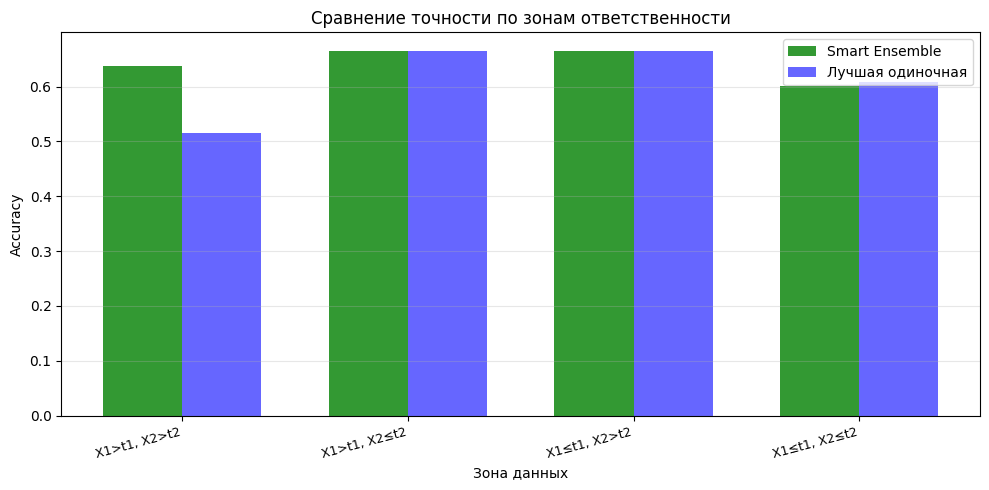

In [186]:
plt.figure(figsize=(10, 5))
zones = df_analysis['Зона']
ens_acc = df_analysis['Acc Ансамбля']
single_acc = df_analysis['Acc Лучшей одиночной']

x = np.arange(len(zones))
width = 0.35

plt.bar(x - width/2, ens_acc, width, label='Smart Ensemble', color='green', alpha=0.8)
plt.bar(x + width/2, single_acc, width, label='Лучшая одиночная', color='blue', alpha=0.6)

plt.xlabel('Зона данных')
plt.ylabel('Accuracy')
plt.title('Сравнение точности по зонам ответственности')
plt.xticks(x, zones, rotation=15, ha='right', fontsize=9)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()